In [1]:
import sys
import os

In [2]:
# Adding the up level folder to path in order to python find the package composed by linear regression implemented
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Local Implementation
from simple_linear_regression import utils
from simple_linear_regression.linear_model import SimpleLinearRegression

# sklearn models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Loading data

In [4]:
df = pd.read_csv("src/pearson_height.csv")

In [5]:
df.head()

,Father,Son
0,65.0,59.8
1,63.3,63.2
2,65.0,63.3
3,65.8,62.8
4,61.1,64.3


# Brief Analysis

In [6]:
df.describe()

,Father,Son
count,1078.000000,1078.000000
mean,67.686827,68.684230
std,2.745827,2.816194
min,59.000000,58.500000
25%,65.800000,66.900000
50%,67.800000,68.600000
75%,69.600000,70.500000
max,75.400000,78.400000


In [7]:
df.isnull().sum()

Father    0
Son       0
dtype: int64

In [8]:
df_long = df.melt(var_name="Feature", value_name="Value")

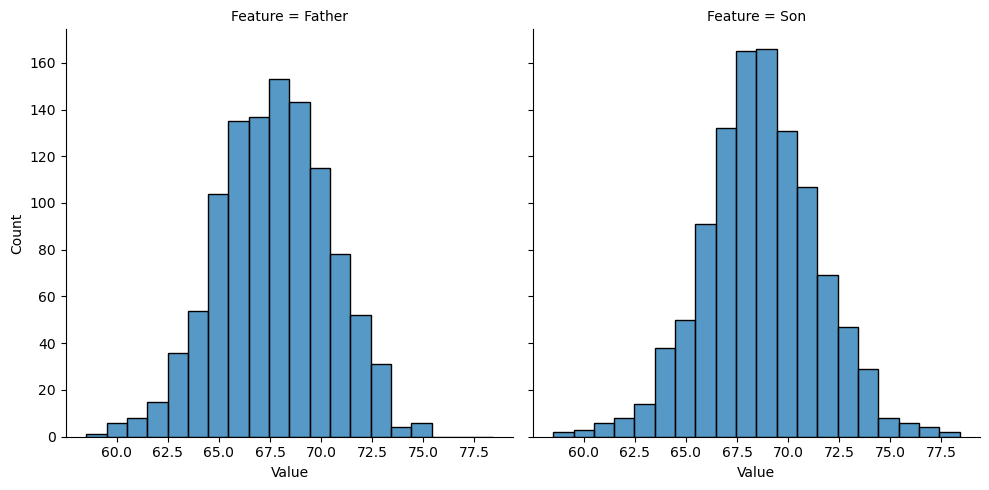

In [9]:
# Histogram for all features
sns.displot(df_long, x="Value", col="Feature", bins=20, kde=False)
plt.show()

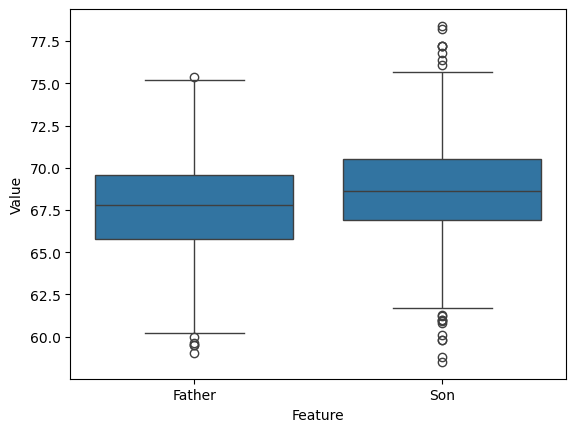

In [10]:
# Boxplot for all features
sns.boxplot(data=df_long, x="Feature", y="Value")
plt.show()

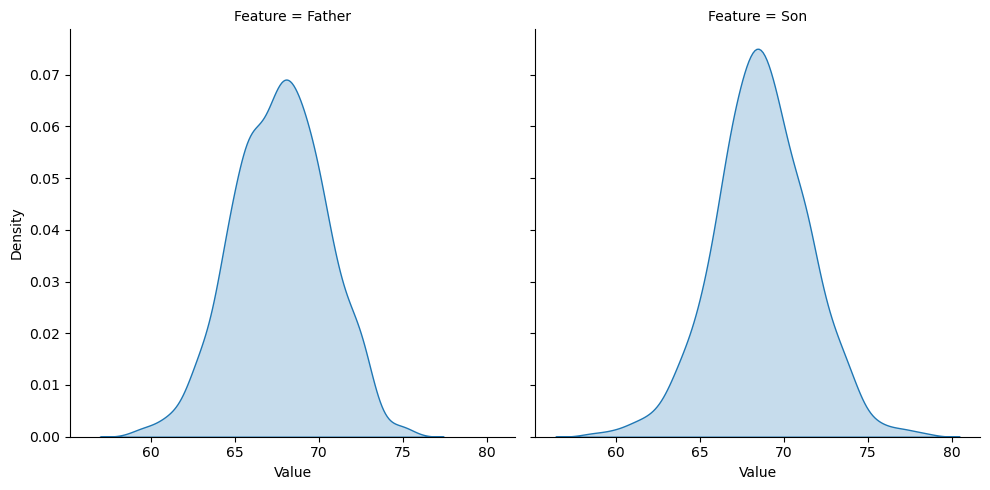

In [11]:
# KDE for all features
sns.displot(df_long, x="Value", col="Feature", kind="kde", fill=True)
plt.show()

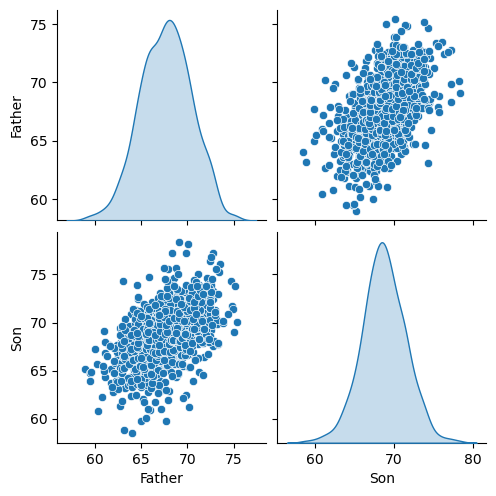

In [12]:
# Pairplot for all features
sns.pairplot(df, diag_kind="kde")
plt.show()

# Split data

In [13]:
seed = 42
train_size = 0.8

In [14]:
X = np.array(df["Father"])
y = np.array(df["Son"])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((862,), (862,), (216,), (216,))

# Saving Data

In [16]:
utils.save_data(use="train", X=X_train, y=y_train, sufix="pearson_height")
utils.save_data(use="test", X=X_test, y=y_test, sufix="pearson_height")

# Normalizing Data

- Its necessary because of the different scale, range of values, is presented for each variable

In [17]:
# Using the internal normalization
X_train_norm_intern = utils.normalization(X_train)
y_train_norm_intern = utils.normalization(y_train)

X_test_norm_intern = utils.normalization(X_test)
y_test_norm_intern = utils.normalization(y_test)

X_train_norm_intern.shape, y_train_norm_intern.shape, X_test_norm_intern.shape, y_test_norm_intern.shape

((862,), (862,), (216,), (216,))

In [18]:
# Using the scikit-learn normalization
scaler = MinMaxScaler()

X_train_norm_skt = scaler.fit_transform(X_train.reshape(-1, 1))
y_train_norm_skt = scaler.fit_transform(y_train.reshape(-1, 1))

X_test_norm_skt = scaler.fit_transform(X_test.reshape(-1, 1))
y_test_norm_skt = scaler.fit_transform(y_test.reshape(-1, 1))

X_train_norm_skt.shape, y_train_norm_skt.shape, X_test_norm_skt.shape, y_test_norm_skt.shape

((862, 1), (862, 1), (216, 1), (216, 1))

# Training model

In [19]:
lr = 0.01           # Learning Rate
tolerance=1e-3
n_iterations = 1e5  # Maximum number of iterations
metric = "mse"      # Metric used - mse: Mean Squared Error
method = "gd"       # Method used - gd: Gradient Descent

In [20]:
intern_model = SimpleLinearRegression(lr=lr, tolerance=tolerance, n_iterations=n_iterations, metric=metric, method=method)

In [21]:
skt_model = LinearRegression()

In [22]:
intern_model.fit(X=X_train_norm_intern, y=y_train_norm_intern)
skt_model.fit(X=X_train_norm_skt, y=y_train_norm_skt)

LinearRegression()

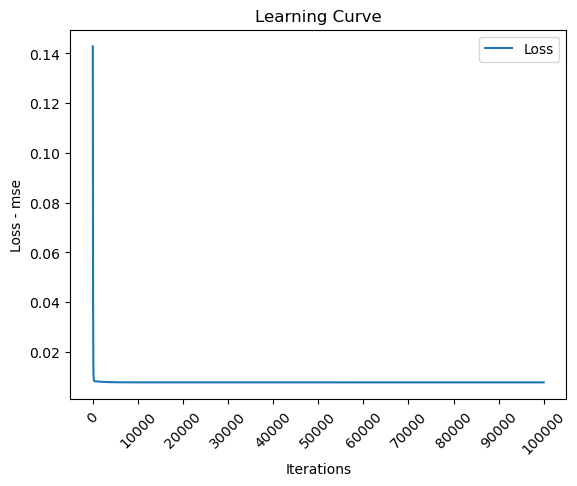

In [23]:
intern_model.learning_curve

In [24]:
intern_model.evaluate(X_train_norm_intern, y_train_norm_intern)

np.float64(0.00778733719112178)

In [25]:
# Predictions
y_pred = skt_model.predict(X_train_norm_skt)
# Evaluation
mse = mean_squared_error(y_train_norm_skt, y_pred)
print(f"MSE: {mse:.3f}")

MSE: 0.016


# Testing Model

In [26]:
intern_model.evaluate(X_test_norm_intern, y_test_norm_intern)

np.float64(0.009447951581617434)

In [27]:
# Predictions
y_pred = skt_model.predict(X_test_norm_skt)
# Evaluation
mse = mean_squared_error(y_test_norm_skt, y_pred)
print(f"MSE: {mse:.3f}")

MSE: 0.019
